In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

from src.data_loader import load_stratified_sample
from src.features import engineer_features
from src.analyzer import get_top_n_per_category, summary_pivot, size_interaction

In [2]:
df = load_stratified_sample()
df_reliable = engineer_features(df)

print(f"df: {df.shape}")
print(f"df_reliable: {df_reliable.shape}")

Cache ditemukan, load langsung dari ..\data\wm811k_v2.pkl
Cache ditemukan, load langsung dari ..\data\wm811k_v3_reliable.pkl
df: (811457, 9)
df_reliable: (809424, 25)


In [3]:
top3_per_category = get_top_n_per_category(df_reliable, n=3)
top3_per_category.to_pickle('../data/top3_per_category.pkl')

print(f"top3_per_category: {top3_per_category.shape}")
print(top3_per_category[['density_global', 'density_center', 'density_edge']])

top3_per_category: (27, 7)
                          density_global  density_center  density_edge
failureType_clean                                                     
Center            573           0.727142        0.961776      0.397924
                  1097          0.717783        0.967941      0.366782
                  1959          0.706983        0.964242      0.346021
Donut             4674          0.678411        0.792593      0.561457
                  4640          0.651032        0.641221      0.660517
                  4689          0.637524        0.779555      0.457701
Edge-Loc          6035          0.746124        0.797872      0.683761
                  7851          0.719493        0.713996      0.725469
                  7533          0.719444        0.753311      0.676471
Edge-Ring         13835         0.451005        0.289786      0.632000
                  17890         0.437186        0.282660      0.610667
                  15906         0.432161        0.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from pathlib import Path

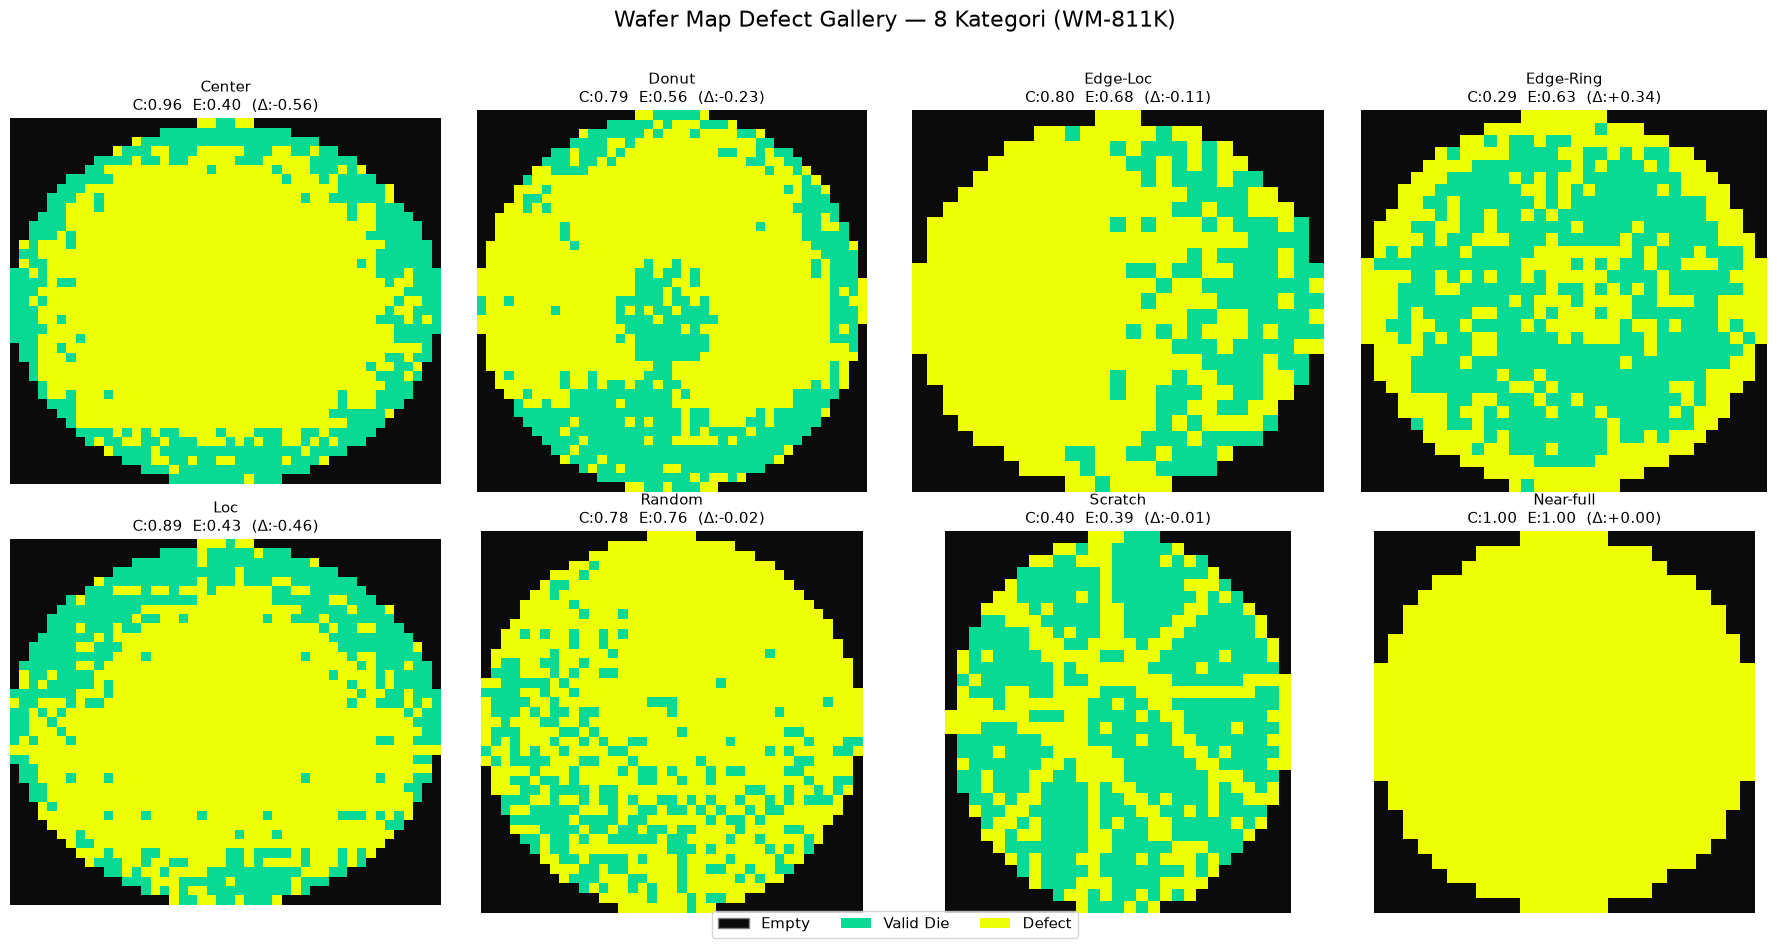

In [18]:
plt.close('all')

categories = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']

# Colormap diskrit: 0=Empty, 1=Valid Die, 2=Defect
cmap = ListedColormap(["#0B0B0B", '#08DA94', '#EEFF05'])
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sample = top3_per_category.loc[cat].iloc[0]  # Opsi A: density tertinggi
    wm = sample['waferMap']

    sns.heatmap(
        wm, cmap=cmap, norm=norm, cbar=False,
        square=True, xticklabels=False, yticklabels=False, ax=axes[i],
    )

    d_center = sample['density_center']
    d_edge = sample['density_edge']
    diff = sample['edge_center_diff']
    axes[i].set_title(
        f"{cat}\nC:{d_center:.2f}  E:{d_edge:.2f}  (\u0394:{diff:+.2f})",
        fontsize=11,
    )

legend_elements = [
    Patch(facecolor="#0B0B0B", edgecolor='gray', label='Empty'),
    Patch(facecolor="#08DA94", label='Valid Die'),
    Patch(facecolor="#EEFF05", label='Defect'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=11)

fig.suptitle('Wafer Map Defect Gallery \u2014 8 Kategori (WM-811K)', fontsize=16, y=1.02)
plt.tight_layout()

Path('../assets').mkdir(exist_ok=True)
plt.savefig('../assets/defect_gallery.png', dpi=150, bbox_inches='tight')
plt.show()